<a href="https://colab.research.google.com/github/wahiwatkar06-gif/mdm-practicals/blob/main/Practical_No9_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
#print(np.__version__)

In [ ]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [ ]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        weight_list.append(self.weights)
        bias_list.append(self.bias)

        return input_gradient

In [ ]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [ ]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [ ]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

Epoch 1/100, Error: 1.095894
Epoch 2/100, Error: 0.796958
Epoch 3/100, Error: 0.582427
Epoch 4/100, Error: 0.428487
Epoch 5/100, Error: 0.318038
Epoch 6/100, Error: 0.238797
Epoch 7/100, Error: 0.181945
Epoch 8/100, Error: 0.141153
Epoch 9/100, Error: 0.111876
Epoch 10/100, Error: 0.090851
Epoch 11/100, Error: 0.075739
Epoch 12/100, Error: 0.064861
Epoch 13/100, Error: 0.057013
Epoch 14/100, Error: 0.051332
Epoch 15/100, Error: 0.047199
Epoch 16/100, Error: 0.044172
Epoch 17/100, Error: 0.041934
Epoch 18/100, Error: 0.040259
Epoch 19/100, Error: 0.038983
Epoch 20/100, Error: 0.037991
Epoch 21/100, Error: 0.037201
Epoch 22/100, Error: 0.036554
Epoch 23/100, Error: 0.036008
Epoch 24/100, Error: 0.035534
Epoch 25/100, Error: 0.035111
Epoch 26/100, Error: 0.034723
Epoch 27/100, Error: 0.034361
Epoch 28/100, Error: 0.034016
Epoch 29/100, Error: 0.033685
Epoch 30/100, Error: 0.033363
Epoch 31/100, Error: 0.033048
Epoch 32/100, Error: 0.032738
Epoch 33/100, Error: 0.032433
Epoch 34/100, Error

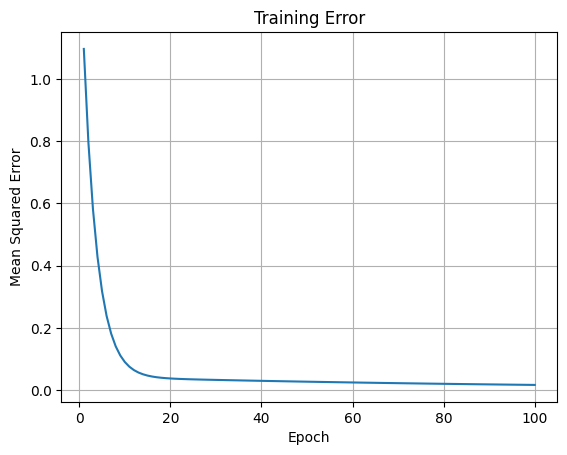

In [ ]:

X = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
Y = np.array([1.2, 1.4, 1.55, 1.75, 2.01, 2.2, 2.35])

network = [
    Dense(1, 1),
    Linear()
]

epochs = 100
learning_rate = 0.01  # Start with a smaller learning rate
errorlist = []
weight_list = []
bias_list = []

for e in range(epochs):
    error = 0.0

    for x, y in zip(X, Y):
        output = np.array([[x]])

        for layer in network:
            output = layer.forward(output)

        error += mse(y, output)
        grad = mse_prime(y, output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)

    error /= len(X)
    errorlist.append(float(error))

    print(f"Epoch {e + 1}/{epochs}, Error: {error:.6f}")

# Final prediction
x_test = np.array([[0.15]])
output = x_test

for layer in network:
    output = layer.forward(output)

print(f"\nPrediction for X = 0.15: {float(np.asarray(output).item()):.4f}")
print(f"Final weight: {network[0].weights}")
print(f"Final bias: {network[0].bias}")

# Plot training error
import matplotlib.pyplot as plt

plt.plot(range(1, epochs + 1), errorlist)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training Error")
plt.grid(True)
plt.show()


In [ ]:
X1 = [0.15]

for x in X1:
    output = x
    for layer in network:
        output=layer.forward(output)
    print(output)

[[1.46101221]]


In [ ]:

import matplotlib.pyplot as plt

In [ ]:
w = weight_list[100][0][0]

In [ ]:
b = bias_list[100][0][0]

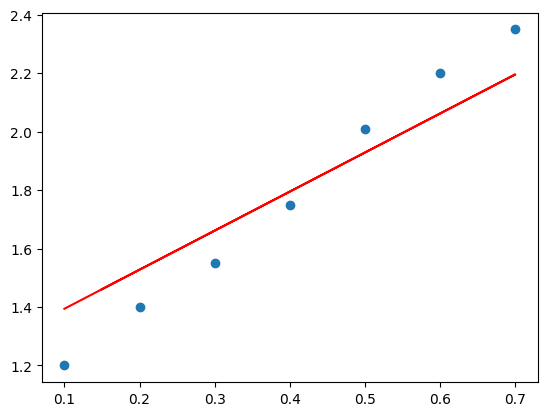

In [ ]:
plt.scatter(X,Y)

x1 = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.15]
y1 = [(w*i + b) for i in x1]
plt.plot(x1, y1, color='r')